# 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from xgboost import XGBClassifier

# 2. Load Dataset


In [5]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 3. Dataset Description

Basic Dataset Information

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


Display Columns

In [7]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


Display Sample Data

In [8]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Statistical Summary

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# 4. Exploratory Data Analysis

Check Missing Values

In [11]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Check Duplicate Records

In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


Check Churn Distribution

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


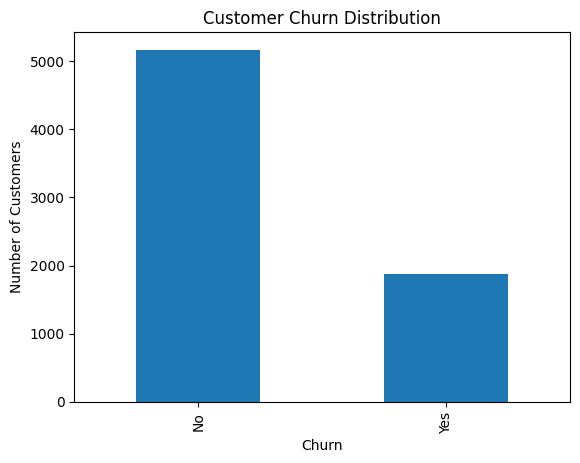

In [13]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)
df['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

Numerical Feature Correlation

In [14]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)
correlation = df.select_dtypes(
    include=['int64', 'float64']
).corr()

print(correlation)

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.102411
tenure               0.016567  1.000000        0.247900      0.825880
MonthlyCharges       0.220173  0.247900        1.000000      0.651065
TotalCharges         0.102411  0.825880        0.651065      1.000000


Correlation Heatmap

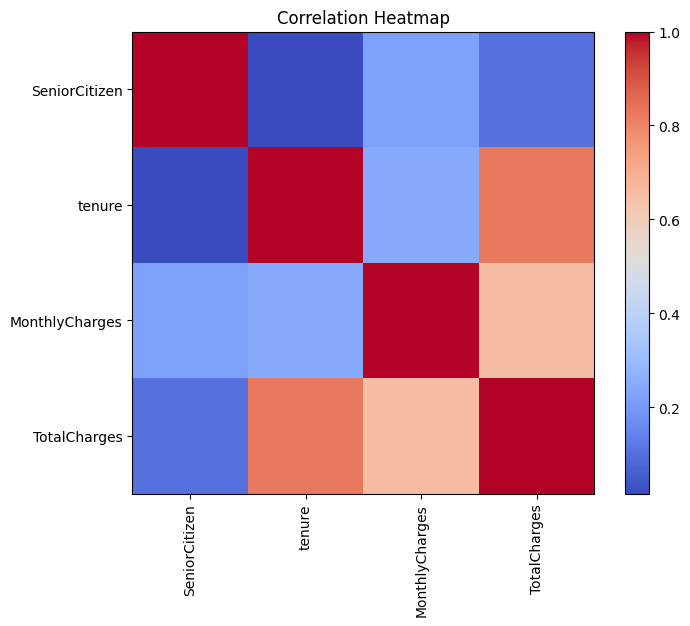

In [15]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation, cmap='coolwarm')

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title('Correlation Heatmap')

plt.show()

Simple Feature Analysis

In [16]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

print(contract_churn)



Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


# 5. Preprocessing

Remove Customer ID

In [17]:
df = df.drop('customerID', axis=1)

Convert Target Variable

In [18]:
df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


Separate Features and Target

In [19]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


Identify Numerical and Categorical Features

In [20]:
numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Train/Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 19)
Testing data: (1409, 19)


# 6. HYPERPARAMETER OPTIMIZATION

5-Fold Stratified Cross-Validation

In [22]:

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Cross-Validation is ready.")

5-Fold Cross-Validation is ready.


# MODEL 1 — XGBOOST

XGBoost Preprocessing

In [23]:
xgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer',
                 SimpleImputer(strategy='median'))
            ]),
            numerical_features
        ),

        (
            'cat',
            Pipeline([
                ('imputer',
                 SimpleImputer(strategy='most_frequent')),

                ('encoder',
                 OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        )
    ]
)

XGBoost Model + Hyperparameter Optimization

In [24]:

# Create XGBoost classifier
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# Combine preprocessing and XGBoost into one pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', xgb_preprocessor),
    ('model', xgb_model)
])

# Define hyperparameters for GridSearchCV
xgb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.05, 0.1]
}

# Perform Grid Search with 5-fold cross-validation
xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Train the model and search for the best parameters
xgb_grid.fit(X_train, y_train)

# Display the best hyperparameters and cross-validation score
print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)

print("\nBest XGBoost CV F1 Score:")
print(xgb_grid.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best XGBoost Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}

Best XGBoost CV F1 Score:
0.5921490642886453


# MODEL 2 — MLP

MLP Preprocessing

In [25]:
mlp_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer',
                 SimpleImputer(strategy='median')),

                ('scaler',
                 StandardScaler())
            ]),
            numerical_features
        ),

        (
            'cat',
            Pipeline([
                ('imputer',
                 SimpleImputer(strategy='most_frequent')),

                ('encoder',
                 OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        )
    ]
)

MLP Model + Hyperparameter Optimization

In [26]:

# Create MLP classifier
mlp_model = MLPClassifier(
    random_state=42,
    max_iter=300,
    early_stopping=True
)

# Combine preprocessing and MLP into one pipeline
mlp_pipeline = Pipeline([
    ('preprocessor', mlp_preprocessor),
    ('model', mlp_model)
])

# Define hyperparameters for GridSearchCV
mlp_param_grid = {
    'model__hidden_layer_sizes': [
        (50,),
        (100,)
    ],
    'model__activation': [
        'relu'
    ],
    'model__learning_rate_init': [
        0.001,
        0.01
    ],
    'model__alpha': [
        0.0001,
        0.001
    ]
}

# Perform Grid Search with 5-fold cross-validation
mlp_grid = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=mlp_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Train the model and search for the best parameters
mlp_grid.fit(X_train, y_train)

# Display the best hyperparameters and cross-validation score
print("Best MLP Parameters:")
print(mlp_grid.best_params_)

print("\nBest MLP CV F1 Score:")
print(mlp_grid.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best MLP Parameters:
{'model__activation': 'relu', 'model__alpha': 0.001, 'model__hidden_layer_sizes': (50,), 'model__learning_rate_init': 0.01}

Best MLP CV F1 Score:
0.5971963478254116


# 7. MODEL EVALUATION

XGBoost Prediction and Evaluation

In [27]:

# Predict the churn classes for the test data
xgb_pred = xgb_grid.predict(X_test)

# Calculate evaluation metrics
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

# Display XGBoost performance
print("XGBoost Performance")
print("-------------------------")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

XGBoost Performance
-------------------------
Accuracy : 0.8076650106458482
Precision: 0.6757679180887372
Recall   : 0.5294117647058824
F1 Score : 0.5937031484257871


MLP Prediction and Evaluation

In [28]:

# Predict the churn classes for the test data
mlp_pred = mlp_grid.predict(X_test)

# Calculate evaluation metrics
mlp_accuracy = accuracy_score(y_test, mlp_pred)
mlp_precision = precision_score(y_test, mlp_pred)
mlp_recall = recall_score(y_test, mlp_pred)
mlp_f1 = f1_score(y_test, mlp_pred)

# Display MLP performance
print("MLP Performance")
print("-------------------------")
print("Accuracy :", mlp_accuracy)
print("Precision:", mlp_precision)
print("Recall   :", mlp_recall)
print("F1 Score :", mlp_f1)

MLP Performance
-------------------------
Accuracy : 0.7934705464868701
Precision: 0.6202898550724638
Recall   : 0.5721925133689839
F1 Score : 0.5952712100139083


Final Performance Table

In [29]:
results = pd.DataFrame({
    'Model': ['XGBoost', 'MLP'],

    'Accuracy': [
        xgb_accuracy,
        mlp_accuracy
    ],

    'Precision': [
        xgb_precision,
        mlp_precision
    ],

    'Recall': [
        xgb_recall,
        mlp_recall
    ],

    'F1 Score': [
        xgb_f1,
        mlp_f1
    ]
})

results
results.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1 Score': '{:.4f}'
})

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.8077,0.6758,0.5294,0.5937
1,MLP,0.7935,0.6203,0.5722,0.5953


# 8. CONFUSION MATRIX

XGBoost Confusion Matrix

[[940  95]
 [176 198]]


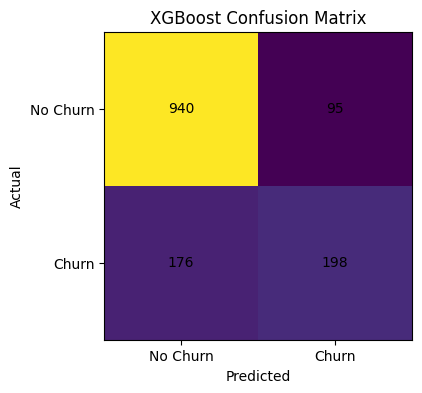

In [30]:
xgb_cm = confusion_matrix(y_test, xgb_pred)
print(xgb_cm)

plt.figure(figsize=(5, 4))

plt.imshow(xgb_cm)

plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.yticks([0, 1], ['No Churn', 'Churn'])

for i in range(2):
    for j in range(2):
        plt.text(
            j, i,
            xgb_cm[i, j],
            ha='center',
            va='center'
        )

plt.show()

MLP Confusion Matrix

[[904 131]
 [160 214]]


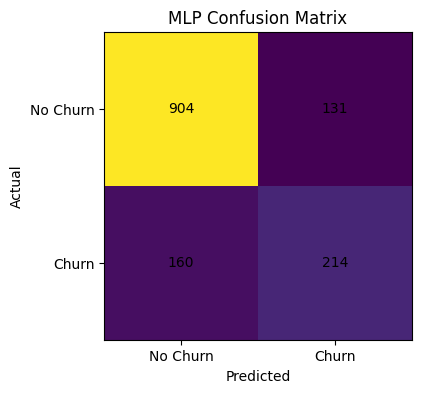

In [31]:
mlp_cm = confusion_matrix(y_test, mlp_pred)
print(mlp_cm)

plt.figure(figsize=(5, 4))

plt.imshow(mlp_cm)

plt.title('MLP Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.yticks([0, 1], ['No Churn', 'Churn'])

for i in range(2):
    for j in range(2):
        plt.text(
            j, i,
            mlp_cm[i, j],
            ha='center',
            va='center'
        )

plt.show()

# 9. ROC CURVE & AUC


XGBoost AUC: 0.8447983673047612
MLP AUC: 0.8414554754708208


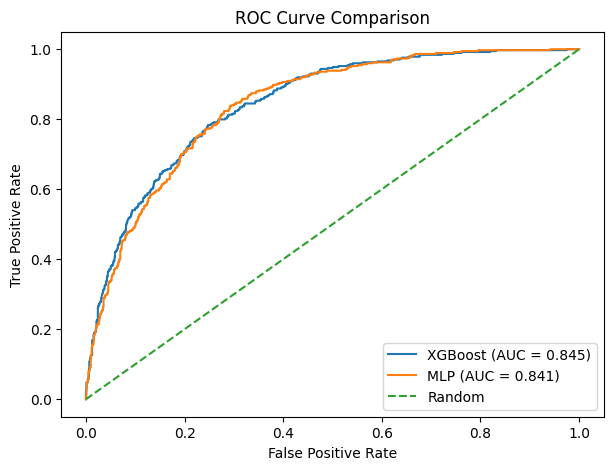

In [32]:
#Get Prediction Probabilities
xgb_prob = xgb_grid.predict_proba(X_test)[:, 1]
mlp_prob = mlp_grid.predict_proba(X_test)[:, 1]

#Calculate AUC
xgb_auc = roc_auc_score(y_test, xgb_prob)

mlp_auc = roc_auc_score(y_test, mlp_prob)

print("XGBoost AUC:", xgb_auc)
print("MLP AUC:", mlp_auc)

#ROC Curve
xgb_fpr, xgb_tpr, _ = roc_curve(
    y_test,
    xgb_prob
)

mlp_fpr, mlp_tpr, _ = roc_curve(
    y_test,
    mlp_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f'XGBoost (AUC = {xgb_auc:.3f})'
)

plt.plot(
    mlp_fpr,
    mlp_tpr,
    label=f'MLP (AUC = {mlp_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

# 10. FEATURE IMPORTANCE — XGBoost

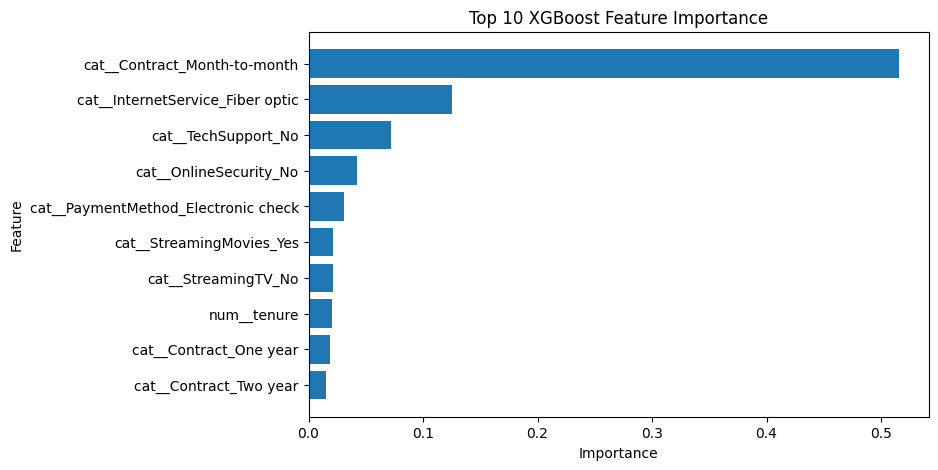

In [33]:
#Get Feature Names
feature_names = (
    xgb_grid
    .best_estimator_
    .named_steps['preprocessor']
    .get_feature_names_out()
)

#Get Feature Importance
importance = (
    xgb_grid
    .best_estimator_
    .named_steps['model']
    .feature_importances_
)

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

#Feature Importance Plot
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.title('Top 10 XGBoost Feature Importance')

plt.gca().invert_yaxis()

plt.show()

# 11. MODEL COMPARISON

Compare Accuracy, Precision, Recall and F1

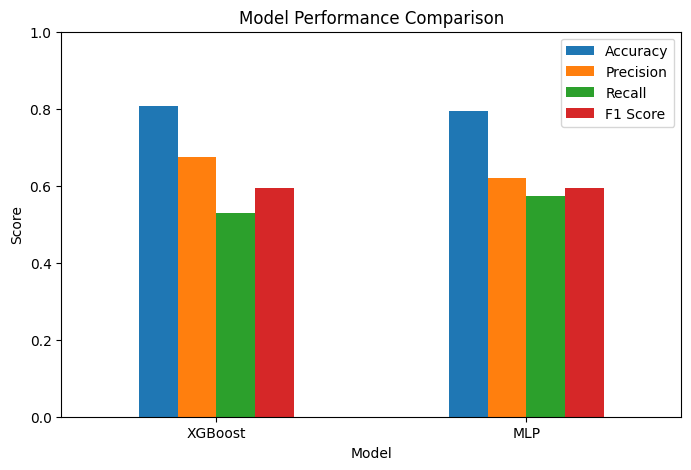

In [34]:
results.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

Determine Best Model

In [35]:
if xgb_f1 > mlp_f1:
    print("XGBoost performed better based on F1-score.")
else:
    print("MLP performed better based on F1-score.")
#Compare AUC
if xgb_auc > mlp_auc:
    print("XGBoost has the higher AUC.")
else:
    print("MLP has the higher AUC.")

MLP performed better based on F1-score.
XGBoost has the higher AUC.


Classification Reports

In [36]:
#XGBoost
print("XGBoost Classification Report")
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

#MLP
print("MLP Classification Report")
print(
    classification_report(
        y_test,
        mlp_pred
    )
)

XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

MLP Classification Report
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1035
           1       0.62      0.57      0.60       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409

